# Сравнение Парето-фронтов


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

SEED = 42
notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
no_llm_dir = notebook_dir / "nsga_2_without_llm"
prompt_dir = notebook_dir / "nsga_2_llm_prompts"

seed42_front_path = no_llm_dir / f"no_llm_pareto_front_{SEED}.jsonl"
seed42_log_path = no_llm_dir / f"no_llm_optimization_log_{SEED}.jsonl"
prompt_front_files = sorted(
    prompt_dir.glob("prompt_*/prompt_*_pareto_front.jsonl"),
    key=lambda path: int(path.parent.name.rsplit("_", 1)[-1]),
)

if not seed42_front_path.exists():
    raise FileNotFoundError(seed42_front_path)
if not seed42_log_path.exists():
    raise FileNotFoundError(seed42_log_path)
if len(prompt_front_files) != 5:
    raise FileNotFoundError(f"Ожидалось 5 prompt-фронтов в {prompt_dir}, найдено {len(prompt_front_files)}")


def read_jsonl(path):
    df = pd.read_json(path, lines=True)
    for col in ["investor_npv", "land_value_gain", "llm score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "scenario_id" not in df.columns:
        df.insert(0, "scenario_id", [f"{path.stem}_{i + 1}" for i in range(len(df))])
    return df


seed42_front = read_jsonl(seed42_front_path)
prompt_fronts = {
    int(path.parent.name.rsplit("_", 1)[-1]): read_jsonl(path)
    for path in prompt_front_files
}

print(f"seed {SEED} no-LLM фронт: {len(seed42_front)} решений")
for prompt_id, df in prompt_fronts.items():
    print(f"prompt {prompt_id} LLM фронт: {len(df)} решений")


seed 42 no-LLM фронт: 14 решений
prompt 1 LLM фронт: 20 решений
prompt 2 LLM фронт: 20 решений
prompt 3 LLM фронт: 20 решений
prompt 4 LLM фронт: 20 решений
prompt 5 LLM фронт: 18 решений


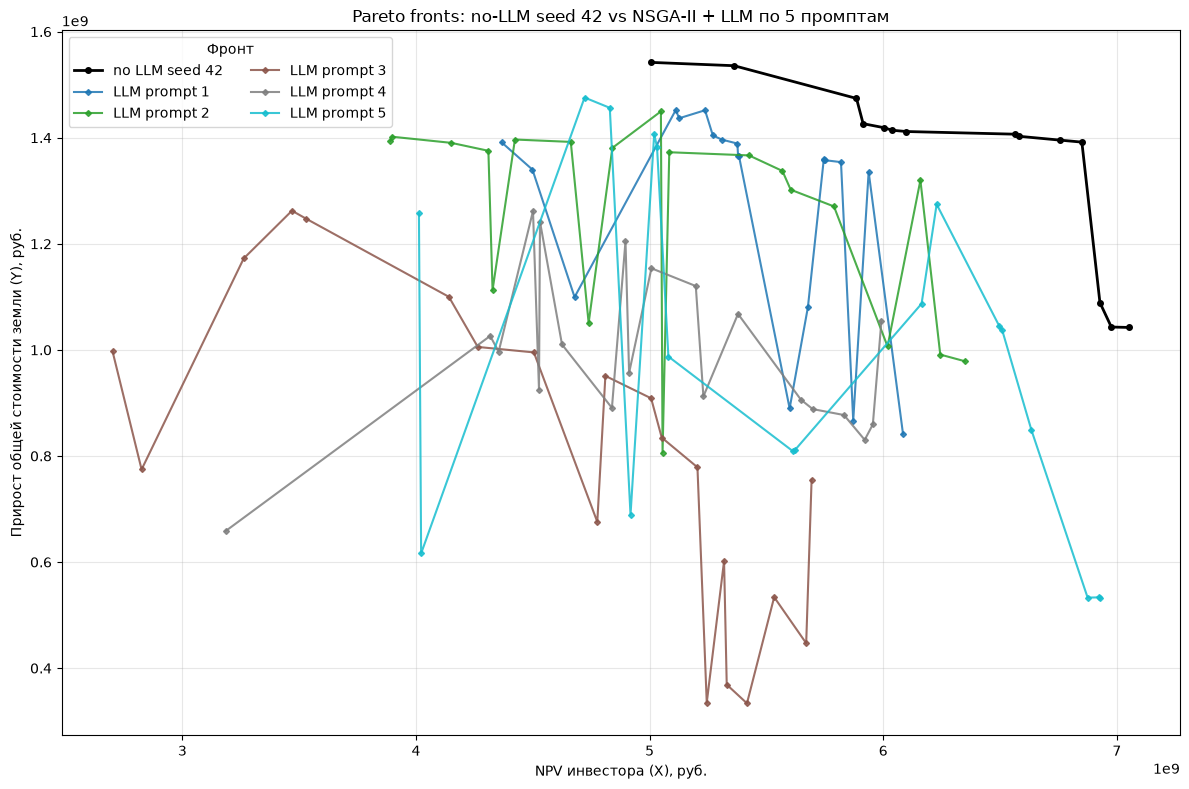

In [2]:
plt.figure(figsize=(12, 8))

base = seed42_front.sort_values("investor_npv")
plt.plot(
    base["investor_npv"],
    base["land_value_gain"],
    marker="o",
    ms=4,
    lw=2.0,
    color="black",
    label=f"no LLM seed {SEED}",
)

cmap = plt.get_cmap("tab10", len(prompt_fronts))
for i, (prompt_id, df) in enumerate(prompt_fronts.items()):
    df = df.sort_values("investor_npv")
    plt.plot(
        df["investor_npv"],
        df["land_value_gain"],
        marker="D",
        ms=3,
        lw=1.5,
        alpha=0.85,
        color=cmap(i),
        label=f"LLM prompt {prompt_id}",
    )

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title(f"Pareto fronts: no-LLM seed {SEED} vs NSGA-II + LLM по 5 промптам")
plt.grid(True, alpha=0.3)
plt.legend(title="Фронт", ncol=2)
plt.tight_layout()
plt.show()


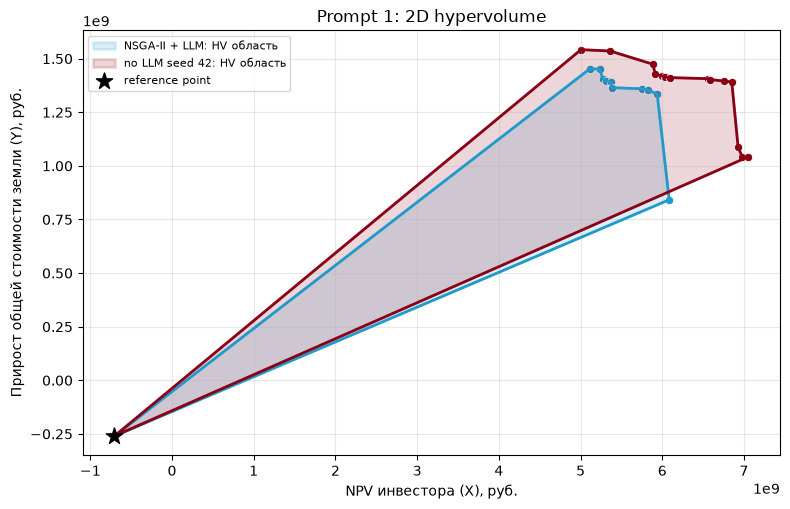

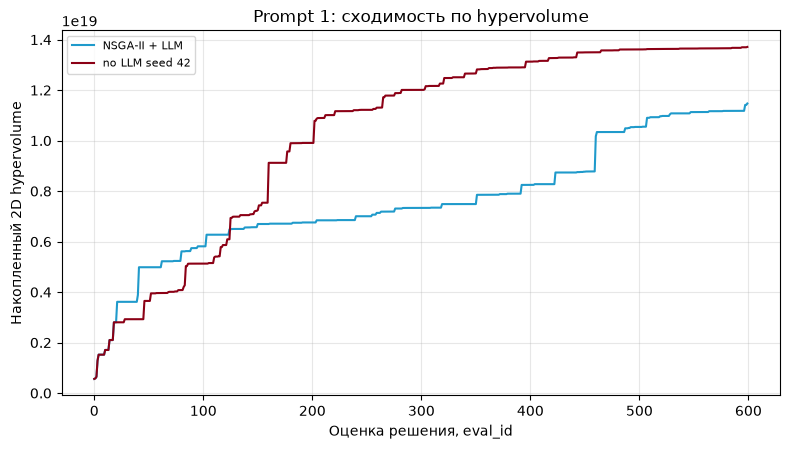

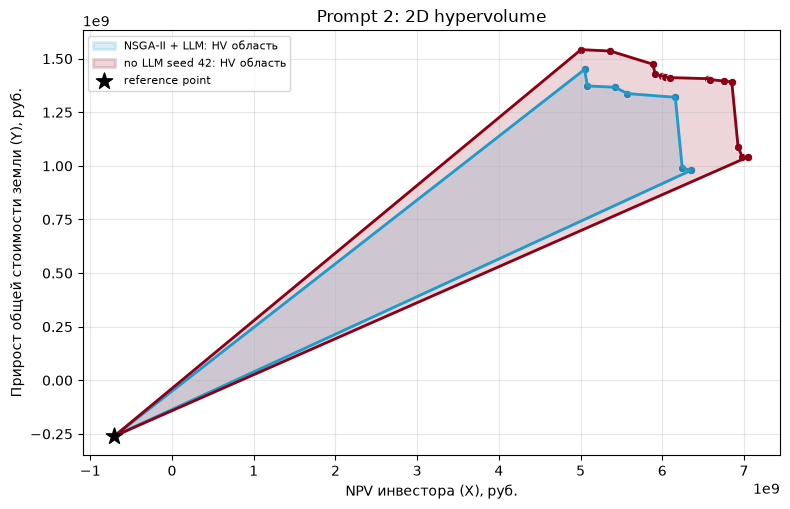

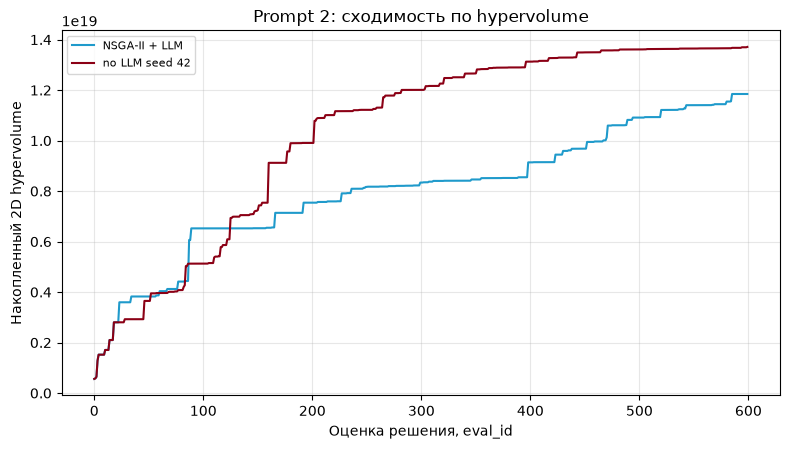

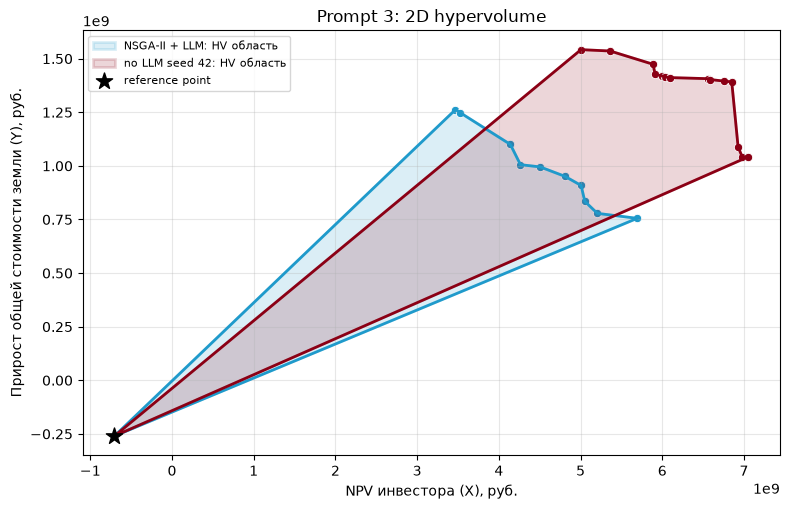

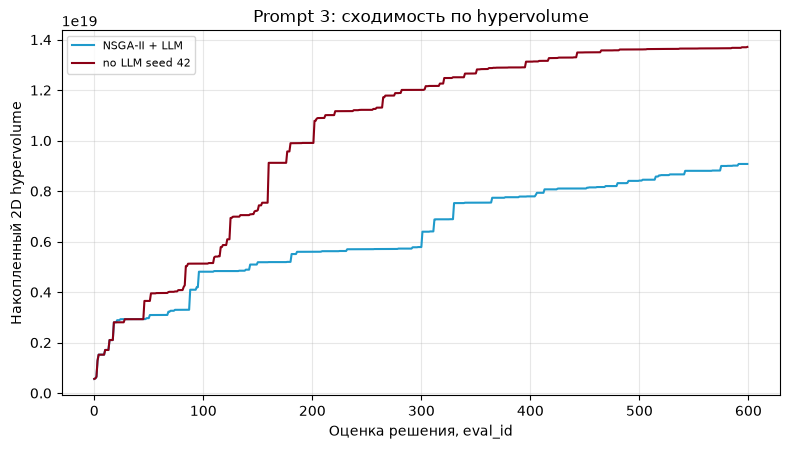

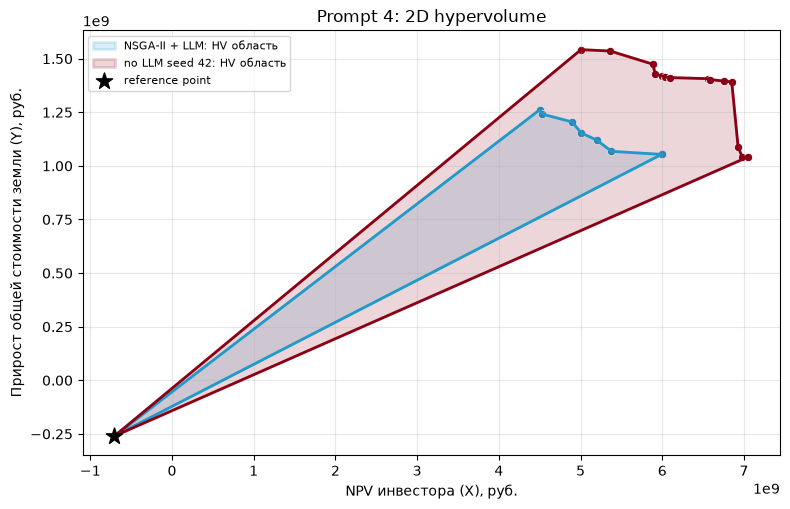

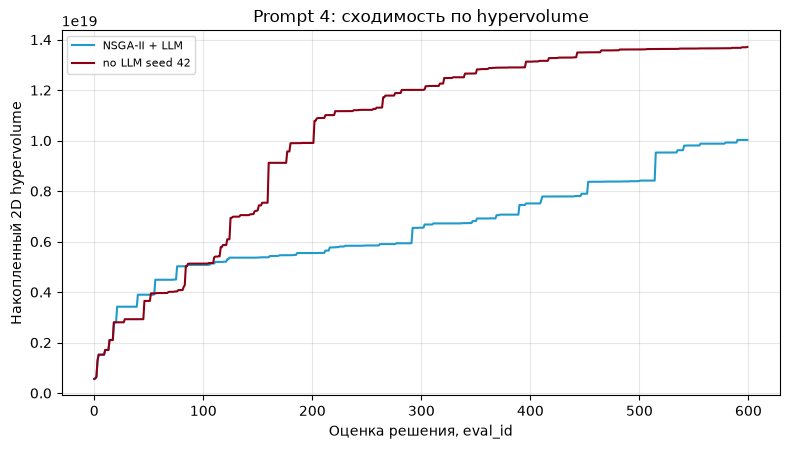

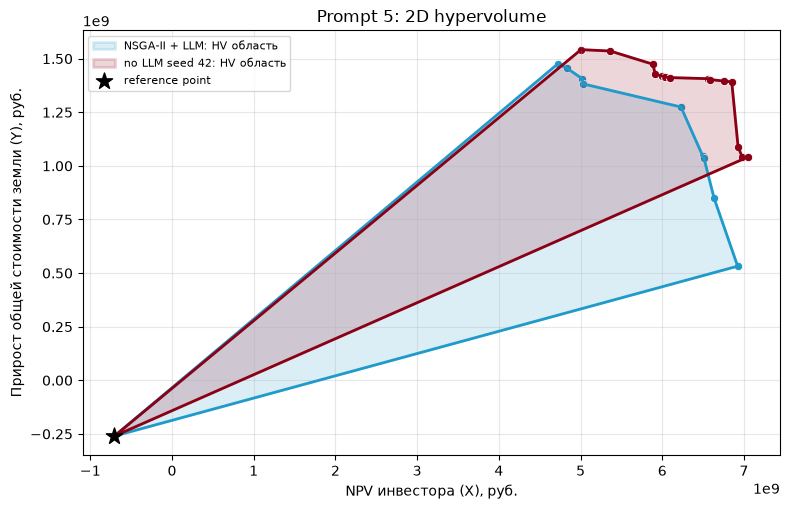

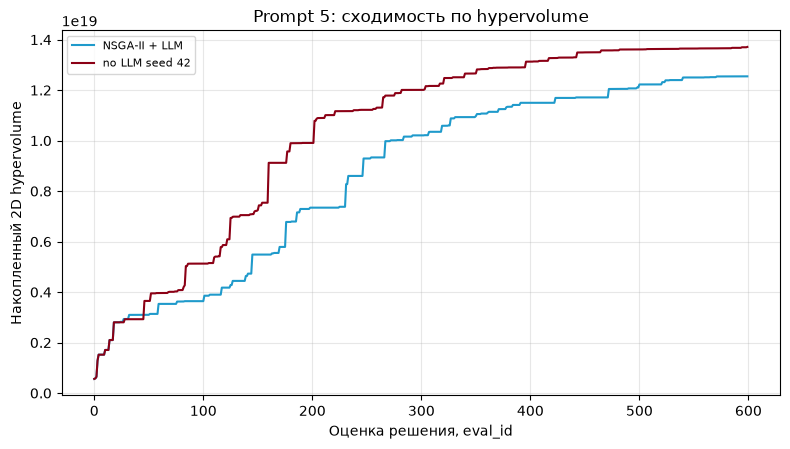

,prompt_id,llm_n_solutions,llm_n_front,llm_hypervolume_2d_norm,no_llm_hypervolume_2d_norm,llm_worse_pct,reference_investor_npv,reference_land_value_gain
0,1,20,12,0.820617,0.980888,16.339302,-7.043852e+08,-2.599695e+08
1,2,20,7,0.847533,0.980888,13.595340,-7.043852e+08,-2.599695e+08
2,3,20,10,0.646577,0.980888,34.082484,-7.043852e+08,-2.599695e+08
3,4,20,7,0.713038,0.980888,27.306885,-7.043852e+08,-2.599695e+08
4,5,18,10,0.895225,0.980888,8.733180,-7.043852e+08,-2.599695e+08


In [6]:
def xy_values(df):
    out = df[["investor_npv", "land_value_gain"]].copy()
    out["investor_npv"] = pd.to_numeric(out["investor_npv"], errors="coerce")
    out["land_value_gain"] = pd.to_numeric(out["land_value_gain"], errors="coerce")
    return out.dropna(subset=["investor_npv", "land_value_gain"])


def nondominated_2d(points):
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    if len(points) == 0:
        return points
    keep = []
    for i, point in enumerate(points):
        others = np.delete(points, i, axis=0)
        keep.append(
            not np.any(
                (others[:, 0] >= point[0])
                & (others[:, 1] >= point[1])
                & ((others[:, 0] > point[0]) | (others[:, 1] > point[1]))
            )
        )
    return np.array(sorted(points[keep], key=lambda point: point[0]))


def hypervolume_2d(points, reference):
    front = nondominated_2d(points)
    hv = 0.0
    prev_x = reference[0]
    for x, y in front:
        hv += max(0.0, x - prev_x) * max(0.0, y - reference[1])
        prev_x = max(prev_x, x)
    return hv, front


def front_polygon_2d(front, reference):
    front = np.asarray(front, dtype=float)
    if len(front) == 0:
        return front
    if np.linalg.norm(front[-1] - reference) < np.linalg.norm(front[0] - reference):
        front = front[::-1]
    return np.vstack([reference, front, reference])


def running_hypervolume(log_path, reference):
    raw = pd.read_json(log_path, lines=True)
    df = xy_values(raw)
    df["eval_id"] = raw.loc[df.index, "eval_id"].to_numpy() if "eval_id" in raw.columns else np.arange(len(df))
    df = df.sort_values("eval_id")

    seen = []
    rows = []
    for _, row in df.iterrows():
        seen.append([row["investor_npv"], row["land_value_gain"]])
        hv, _ = hypervolume_2d(seen, reference)
        rows.append({"eval_id": row["eval_id"], "hypervolume_2d": hv})
    return pd.DataFrame(rows)


colors = {"NSGA-II + LLM": "#1f9acb", f"no LLM seed {SEED}": "#8b0015"}
no_llm_log_path = no_llm_dir / f"no_llm_optimization_log_{SEED}.jsonl"
hypervolume_rows = []
no_llm_row_added = False

for prompt_id, llm_front_raw in sorted(prompt_fronts.items()):
    llm_label = "NSGA-II + LLM"
    no_llm_label = f"no LLM seed {SEED}"
    llm_log_path = prompt_dir / f"prompt_{prompt_id}" / f"prompt_{prompt_id}_optimization_log.jsonl"

    llm_front = xy_values(llm_front_raw)
    no_llm_front = xy_values(seed42_front)
    all_solutions = pd.concat(
        [xy_values(pd.read_json(llm_log_path, lines=True)), xy_values(pd.read_json(no_llm_log_path, lines=True))],
        ignore_index=True,
    )
    points_all = all_solutions[["investor_npv", "land_value_gain"]].to_numpy(float)
    reference = points_all.min(axis=0)
    norm = np.prod(points_all.max(axis=0) - reference)

    fronts = {}
    metrics = {}
    for label, df in [(llm_label, llm_front), (no_llm_label, no_llm_front)]:
        points = df[["investor_npv", "land_value_gain"]].to_numpy(float)
        hv, front = hypervolume_2d(points, reference)
        fronts[label] = front
        metrics[label] = {
            "n_solutions": len(df),
            "n_front": len(front),
            "hypervolume_2d": hv,
            "hypervolume_2d_norm": hv / norm if norm else np.nan,
        }

    llm_hv = metrics[llm_label]["hypervolume_2d_norm"]
    no_llm_hv = metrics[no_llm_label]["hypervolume_2d_norm"]
    if not no_llm_row_added:
        hypervolume_rows.append(
            {
                "prompt_id": f"seed {SEED}",
                "algorithm": no_llm_label,
                "n_solutions": metrics[no_llm_label]["n_solutions"],
                "n_front": metrics[no_llm_label]["n_front"],
                "hypervolume_2d_norm": no_llm_hv,
                "llm_worse_pct": 0.0,
            }
        )
        no_llm_row_added = True
    hypervolume_rows.append(
        {
            "prompt_id": prompt_id,
            "algorithm": llm_label,
            "n_solutions": metrics[llm_label]["n_solutions"],
            "n_front": metrics[llm_label]["n_front"],
            "hypervolume_2d_norm": llm_hv,
            "llm_worse_pct": (no_llm_hv - llm_hv) / no_llm_hv * 100 if no_llm_hv else np.nan,
        }
    )

    plt.figure(figsize=(8, 5.2))
    for label, front in fronts.items():
        polygon = front_polygon_2d(front, reference)
        plt.fill(
            polygon[:, 0],
            polygon[:, 1],
            facecolor=colors[label],
            edgecolor=colors[label],
            linewidth=2.0,
            alpha=0.16,
            label=f"{label}: HV область",
        )
        plt.plot(polygon[:, 0], polygon[:, 1], color=colors[label], lw=2.0)
        plt.scatter(front[:, 0], front[:, 1], s=36, color=colors[label], edgecolor="white", linewidth=0.6)
    plt.scatter(reference[0], reference[1], marker="*", s=150, c="black", label="reference point", zorder=5)
    plt.xlabel("NPV инвестора (X), руб.")
    plt.ylabel("Прирост общей стоимости земли (Y), руб.")
    plt.title(f"Prompt {prompt_id}: 2D hypervolume")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.6))
    for label, log_path in [(llm_label, llm_log_path), (no_llm_label, no_llm_log_path)]:
        running = running_hypervolume(log_path, reference)
        plt.plot(running["eval_id"], running["hypervolume_2d"], color=colors[label], label=label)
    plt.xlabel("Оценка решения, eval_id")
    plt.ylabel("Накопленный 2D hypervolume")
    plt.title(f"Prompt {prompt_id}: сходимость по hypervolume")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

hypervolume_by_prompt = pd.DataFrame(hypervolume_rows)
display(hypervolume_by_prompt)


# LLM score для seed 42 по пяти промптам


In [ ]:
prompts = {
    1: """
Evaluate the presented scenario based on the criterion of social inclusiveness and low displacement risk.
Determine whether the scenario preserves the social and functional diversity of the area, access to everyday services, and opportunities for vulnerable user groups.
Assign a score from 0 to 1.
""".strip(),
    2: """
Evaluate the presented scenario based on the criterion of strategic relevance for the long-term development of the city and district.
Consider compactness, functional mix, the balance of housing, jobs, and services, and the area's ability to adapt to future changes.
Assign a score from 0 to 1.
""".strip(),
    3: """
Evaluate the presented scenario based on its ability to create conditions for active urban life.
Consider functional mix, the potential for active ground floors, pedestrian accessibility, public spaces, and diverse everyday use scenarios throughout the day and evening.
Assign a score from 0 to 1.
""".strip(),
    4: """
Evaluate the presented scenario based on the criterion of aligning the interests of various land users and minimizing conflict risk.
Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.
Assign a score from 0 to 1.
""".strip(),
    5: """
Evaluate the presented scenario based on the criterion of environmental and infrastructure sustainability.
Consider building density, transport and infrastructure load, resource efficiency, environmental consequences, and the possibility of phased adaptation of the area.
Assign a score from 0 to 1.
""".strip(),
}


In [ ]:
from urbanomy.methods.agent import SingleAgentBaseline, init_llm
from urbanomy.methods.land_value_modeling import Evaluation, StrategicAlignmentScorer

llm = init_llm("deepseek/deepseek-v4-flash")
baseline = SingleAgentBaseline(llm=llm, output_schema=Evaluation)
json_rule = '\nReturn only valid JSON, no markdown: {"score": 0.0}'
scored_seed42 = {}

for prompt_id, prompt in prompts.items():
    out_path = prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl"
    out_path.parent.mkdir(parents=True, exist_ok=True)

    df = read_jsonl(out_path) if out_path.exists() else seed42_front.copy()
    if "prompt_id" not in df.columns:
        df.insert(0, "prompt_id", prompt_id)
    if "llm score" not in df.columns:
        df["llm score"] = pd.NA

    scorer = StrategicAlignmentScorer(baseline=baseline, prompt=prompt + json_rule)
    missing = df["llm score"].isna()
    for idx, row in df.loc[missing].iterrows():
        scored = scorer.score_candidate(
            params_repaired=row["params_repaired"],
            land_value_gain=row["land_value_gain"],
            investor_npv=row["investor_npv"],
        )
        df.at[idx, "prompt_id"] = prompt_id
        df.at[idx, "llm score"] = scored["score"]
        df.to_json(out_path, orient="records", lines=True, force_ascii=False)

    df["llm score"] = pd.to_numeric(df["llm score"], errors="coerce")
    df.to_json(out_path, orient="records", lines=True, force_ascii=False)
    scored_seed42[prompt_id] = df

score_summary = pd.DataFrame([
    {
        "prompt_id": prompt_id,
        "n": len(df),
        "mean_llm_score": df["llm score"].mean(),
        "median_llm_score": df["llm score"].median(),
        "min_llm_score": df["llm score"].min(),
        "max_llm_score": df["llm score"].max(),
        "path": str(prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl"),
    }
    for prompt_id, df in scored_seed42.items()
])
display(score_summary)


,prompt_id,projection,llm_variant,baseline_variant,llm_n_solutions,llm_n_front,llm_hypervolume_norm,baseline_n_solutions,baseline_n_front,baseline_hypervolume_norm,llm_better_worse_pct
0,1,3D: NPV инвестора × прирост стоимости земли × ...,prompt 1: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,20,0.357667,14,14,0.385840,-7.301934
1,1,2D: прирост стоимости земли × LLM score,prompt 1: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,6,0.703177,14,3,0.523871,34.227335
2,1,2D: NPV инвестора × LLM score,prompt 1: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,6,0.565452,14,4,0.468716,20.638375
3,2,3D: NPV инвестора × прирост стоимости земли × ...,prompt 2: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,20,0.449611,14,14,0.346209,29.867079
4,2,2D: прирост стоимости земли × LLM score,prompt 2: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,7,0.751777,14,4,0.373201,101.440518
5,2,2D: NPV инвестора × LLM score,prompt 2: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,4,0.666948,14,2,0.560196,19.056282
6,3,3D: NPV инвестора × прирост стоимости земли × ...,prompt 3: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,20,0.246988,14,14,0.272228,-9.271773
7,3,2D: прирост стоимости земли × LLM score,prompt 3: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,4,0.670093,14,2,0.287932,132.726176
8,3,2D: NPV инвестора × LLM score,prompt 3: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,7,0.603390,14,3,0.290084,108.004901
9,4,3D: NPV инвестора × прирост стоимости земли × ...,prompt 4: NSGA-II + LLM,"seed 42: NSGA-II без LLM, оцененный тем же LLM...",20,20,0.296230,14,14,0.370482,-20.041987


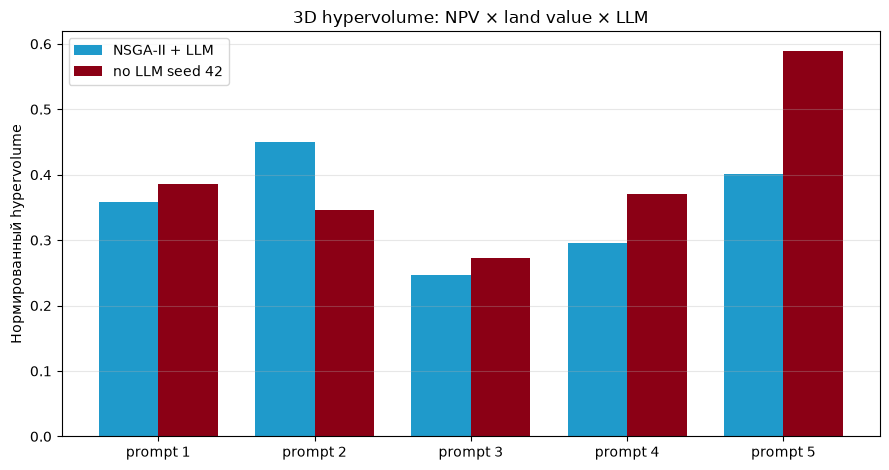

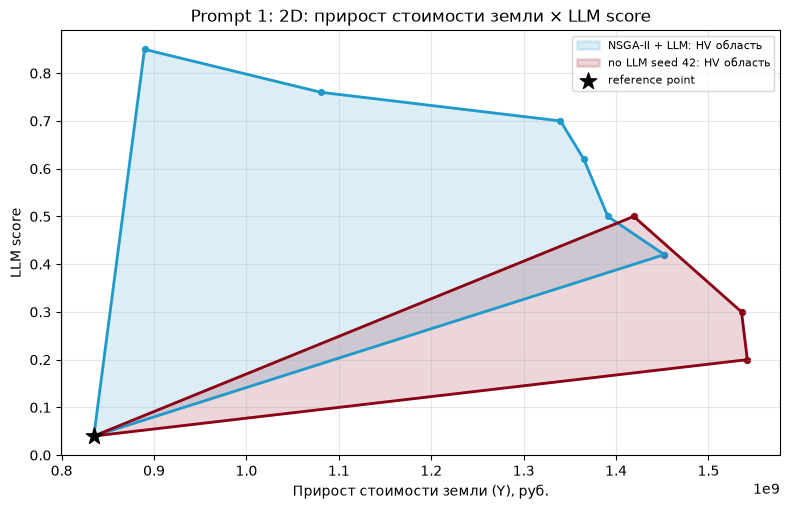

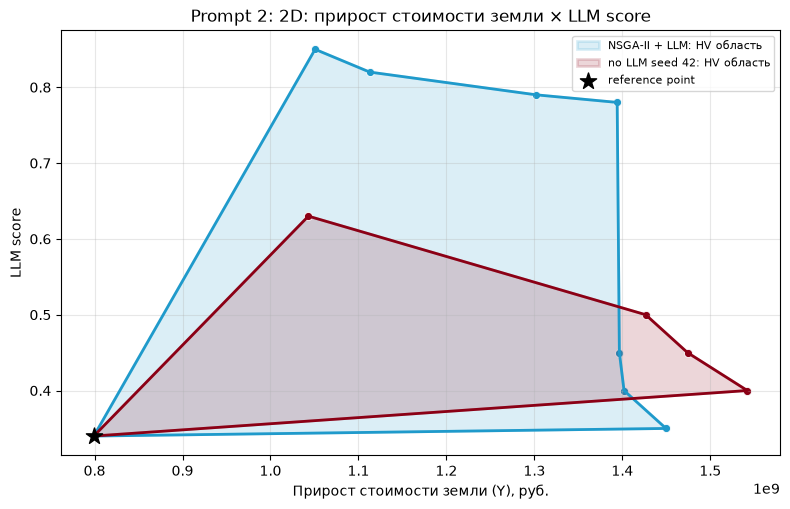

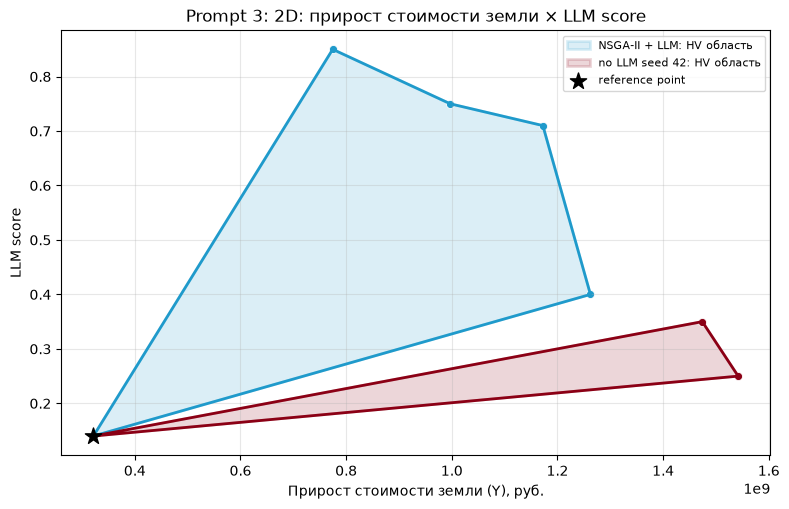

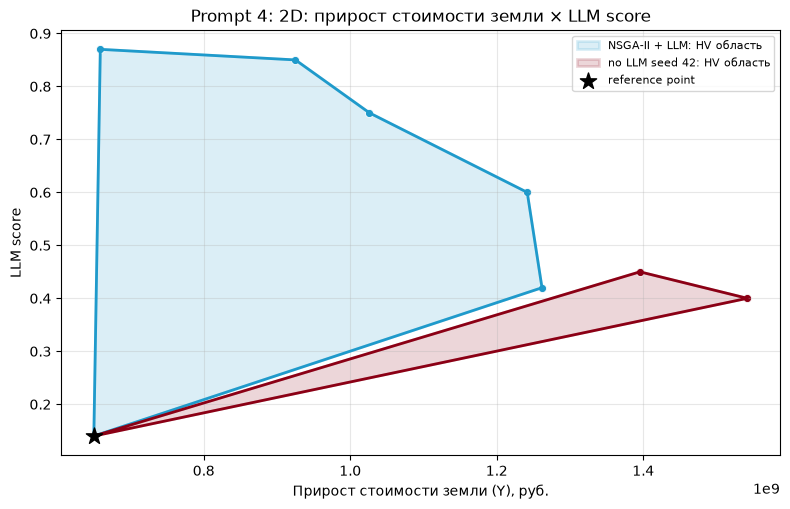

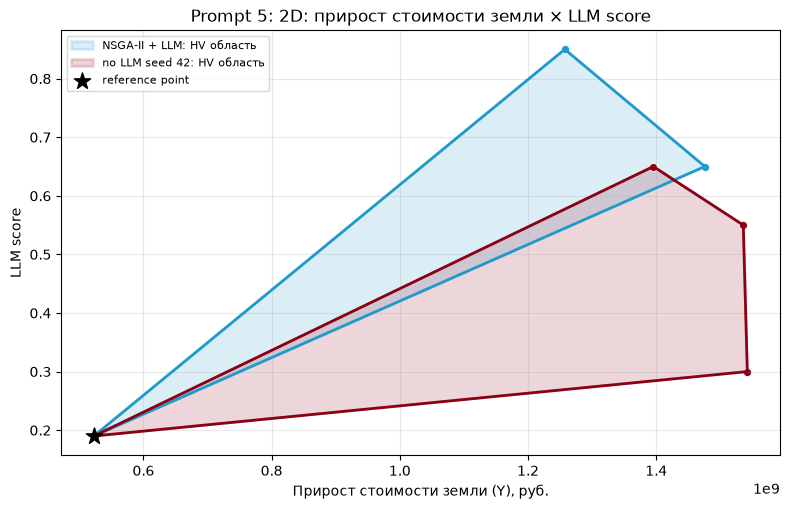

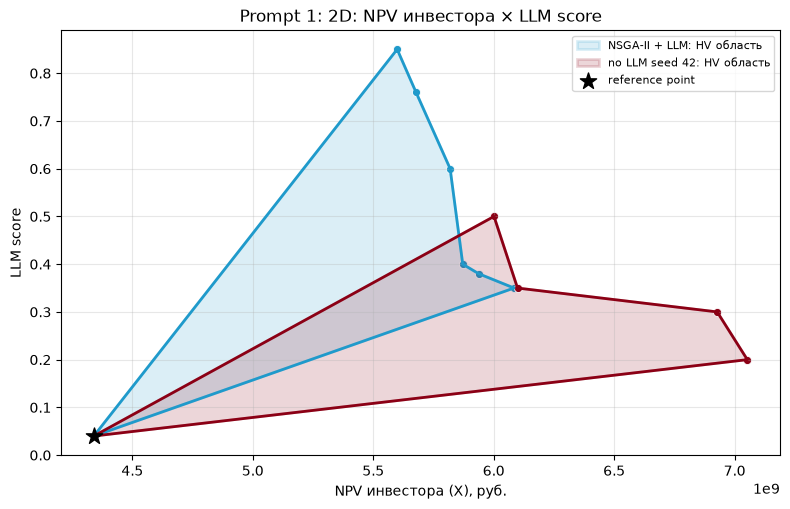

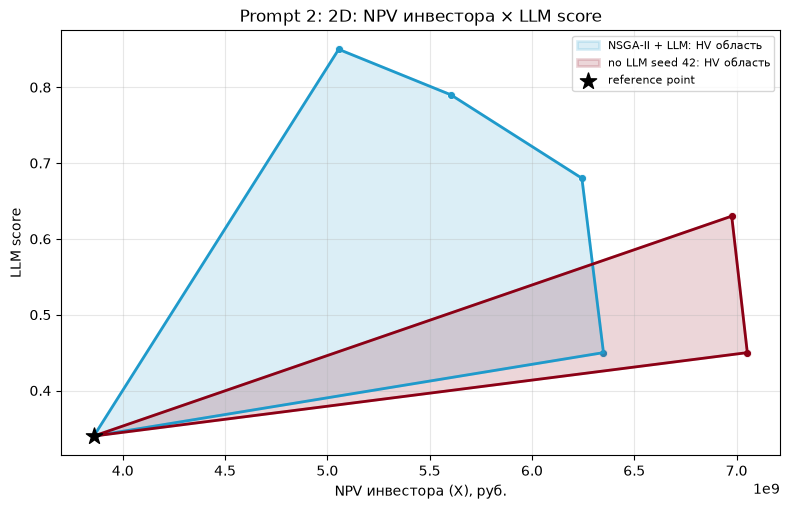

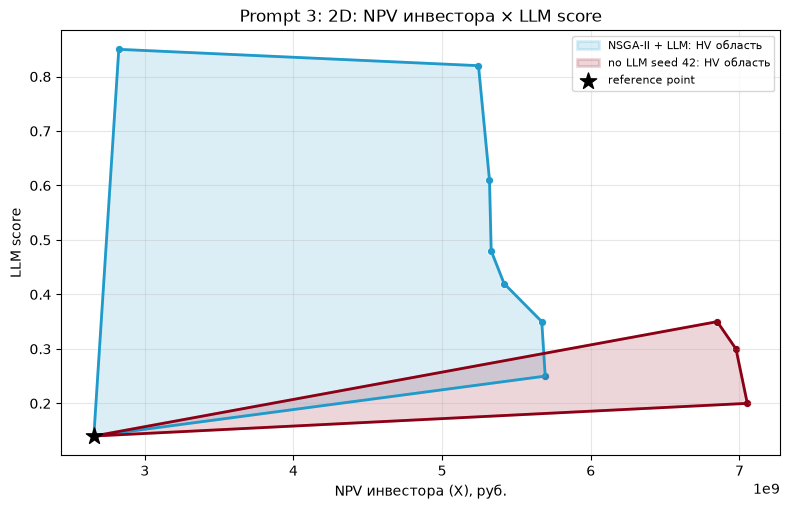

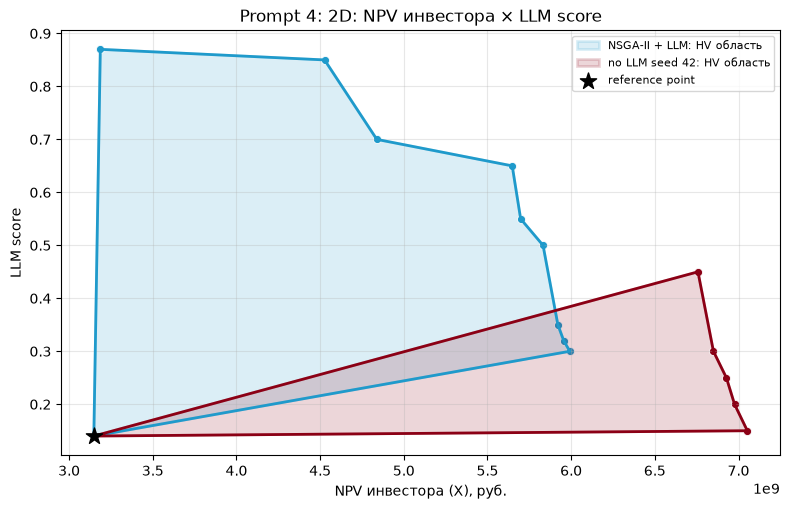

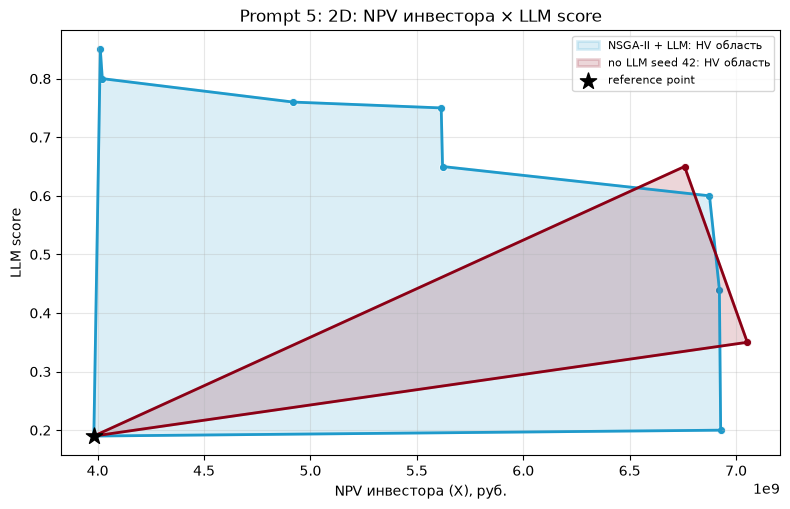

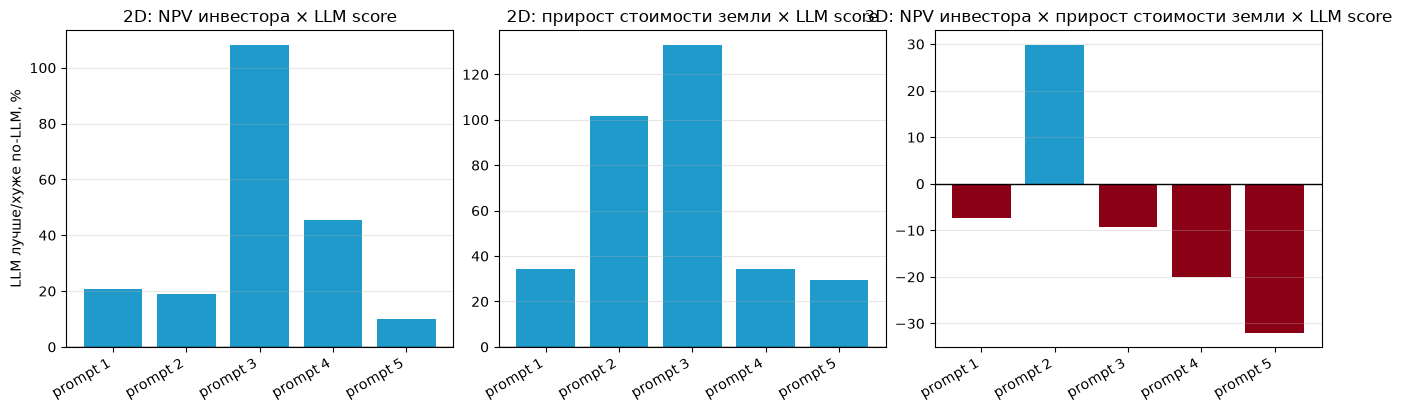

In [12]:
if "scored_seed42" not in globals():
    scored_seed42 = {
        prompt_id: read_jsonl(prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl")
        for prompt_id in prompt_fronts
        if (prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl").exists()
    }


def nondominated(points):
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    keep = []
    for i, point in enumerate(points):
        others = np.delete(points, i, axis=0)
        keep.append(not np.any(np.all(others >= point, axis=1) & np.any(others > point, axis=1)))
    return points[keep]


def hypervolume_2d(points, reference):
    front = np.array(sorted(nondominated(points), key=lambda point: point[0]))
    hv = 0.0
    prev_x = reference[0]
    for x, y in front:
        hv += max(0.0, x - prev_x) * max(0.0, y - reference[1])
        prev_x = max(prev_x, x)
    return hv, front


def hypervolume_3d(points, reference):
    front = nondominated(points)
    if len(front) == 0:
        return 0.0, front

    xs = np.unique(np.r_[reference[0], front[:, 0]])
    ys = np.unique(np.r_[reference[1], front[:, 1]])
    zs = np.unique(np.r_[reference[2], front[:, 2]])
    hv = 0.0
    for x0, x1 in zip(xs[:-1], xs[1:]):
        for y0, y1 in zip(ys[:-1], ys[1:]):
            for z0, z1 in zip(zs[:-1], zs[1:]):
                if np.any(np.all(front >= [x1, y1, z1], axis=1)):
                    hv += (x1 - x0) * (y1 - y0) * (z1 - z0)
    return hv, front


def front_polygon_2d(front, reference):
    front = np.asarray(front, dtype=float)
    if len(front) == 0:
        return front
    if np.linalg.norm(front[-1] - reference) < np.linalg.norm(front[0] - reference):
        front = front[::-1]
    return np.vstack([reference, front, reference])


def prep_llm_scale(df):
    out = df.copy()
    out["llm_score"] = pd.to_numeric(out["llm score"], errors="coerce")
    out["investor_npv"] = pd.to_numeric(out["investor_npv"], errors="coerce")
    out["land_value_gain"] = pd.to_numeric(out["land_value_gain"], errors="coerce")
    return out.dropna(subset=["investor_npv", "land_value_gain", "llm_score"])


def reference_for(values):
    values = np.asarray(values, dtype=float)
    return values.min(axis=0) - np.maximum(np.ptp(values, axis=0) * 0.01, 0.01)


projection_specs = [
    ("3D: NPV инвестора × прирост стоимости земли × LLM score", ["investor_npv", "land_value_gain", "llm_score"], hypervolume_3d),
    ("2D: прирост стоимости земли × LLM score", ["land_value_gain", "llm_score"], hypervolume_2d),
    ("2D: NPV инвестора × LLM score", ["investor_npv", "llm_score"], hypervolume_2d),
]
rows = []
projection_points = {}

for prompt_id in sorted(prompt_fronts):
    if prompt_id not in scored_seed42:
        continue

    llm_variant = f"prompt {prompt_id}: NSGA-II + LLM"
    baseline_variant = f"seed {SEED}: NSGA-II без LLM, оцененный тем же LLM prompt {prompt_id}"
    fronts = {
        llm_variant: prep_llm_scale(prompt_fronts[prompt_id]),
        baseline_variant: prep_llm_scale(scored_seed42[prompt_id]),
    }

    for projection, cols, hv_func in projection_specs:
        all_values = pd.concat(fronts.values(), ignore_index=True)[cols].to_numpy(float)
        reference = reference_for(all_values)
        norm = np.prod(all_values.max(axis=0) - reference)
        metrics = {}

        for algorithm, df in fronts.items():
            values = df[cols].to_numpy(float)
            hv, front = hv_func(values, reference)
            metrics[algorithm] = {
                "n_solutions": len(df),
                "n_front": len(front),
                "hypervolume_norm": hv / norm if norm else np.nan,
            }
            if len(cols) == 2:
                projection_points[(prompt_id, projection, algorithm)] = (values, front, reference)

        llm_hv = metrics[llm_variant]["hypervolume_norm"]
        no_llm_hv = metrics[baseline_variant]["hypervolume_norm"]
        rows.append(
            {
                "prompt_id": prompt_id,
                "projection": projection,
                "llm_variant": llm_variant,
                "baseline_variant": baseline_variant,
                "llm_n_solutions": metrics[llm_variant]["n_solutions"],
                "llm_n_front": metrics[llm_variant]["n_front"],
                "llm_hypervolume_norm": llm_hv,
                "baseline_n_solutions": metrics[baseline_variant]["n_solutions"],
                "baseline_n_front": metrics[baseline_variant]["n_front"],
                "baseline_hypervolume_norm": no_llm_hv,
                "llm_better_worse_pct": (llm_hv - no_llm_hv) / no_llm_hv * 100 if no_llm_hv else np.nan,
            }
        )

hypervolume_llm_scale = pd.DataFrame(rows)
display(hypervolume_llm_scale)

plot_df = hypervolume_llm_scale[hypervolume_llm_scale["projection"].str.startswith("3D")].set_index("prompt_id")
x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(9, 4.8))
plt.bar(x - width / 2, plot_df["llm_hypervolume_norm"], width, label="NSGA-II + LLM", color="#1f9acb")
plt.bar(x + width / 2, plot_df["baseline_hypervolume_norm"], width, label=f"no LLM seed {SEED}", color="#8b0015")
plt.xticks(x, [f"prompt {prompt_id}" for prompt_id in plot_df.index])
plt.ylabel("Нормированный hypervolume")
plt.title("3D hypervolume: NPV × land value × LLM")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for projection, cols, _ in projection_specs[1:]:
    for prompt_id in sorted(prompt_fronts):
        plt.figure(figsize=(8, 5.2))
        llm_variant = f"prompt {prompt_id}: NSGA-II + LLM"
        baseline_variant = f"seed {SEED}: NSGA-II без LLM, оцененный тем же LLM prompt {prompt_id}"
        for algorithm, label, color in [
            (llm_variant, "NSGA-II + LLM", "#1f9acb"),
            (baseline_variant, f"no LLM seed {SEED}", "#8b0015"),
        ]:
            _, front, reference = projection_points[(prompt_id, projection, algorithm)]
            polygon = front_polygon_2d(front, reference)
            plt.fill(
                polygon[:, 0],
                polygon[:, 1],
                facecolor=color,
                edgecolor=color,
                linewidth=2.0,
                alpha=0.16,
                label=f"{label}: HV область",
            )
            plt.plot(polygon[:, 0], polygon[:, 1], color=color, lw=2.0)
            plt.scatter(front[:, 0], front[:, 1], s=34, color=color, edgecolor="white", linewidth=0.6)
        plt.scatter(reference[0], reference[1], marker="*", s=150, c="black", label="reference point", zorder=5)
        plt.xlabel("Прирост стоимости земли (Y), руб." if cols[0] == "land_value_gain" else "NPV инвестора (X), руб.")
        plt.ylabel("LLM score")
        plt.title(f"Prompt {prompt_id}: {projection}")
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

pct_df = hypervolume_llm_scale.pivot(index="prompt_id", columns="projection", values="llm_better_worse_pct")
fig, axes = plt.subplots(1, len(pct_df.columns), figsize=(4.4 * len(pct_df.columns), 4.0), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, projection in zip(axes, pct_df.columns):
    values = pct_df[projection]
    colors = np.where(values >= 0, "#1f9acb", "#8b0015")
    ax.bar(np.arange(len(values)), values, color=colors)
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(np.arange(len(values)), [f"prompt {prompt_id}" for prompt_id in values.index], rotation=30, ha="right")
    ax.set_title(projection)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("LLM лучше/хуже no-LLM, %")
plt.show()


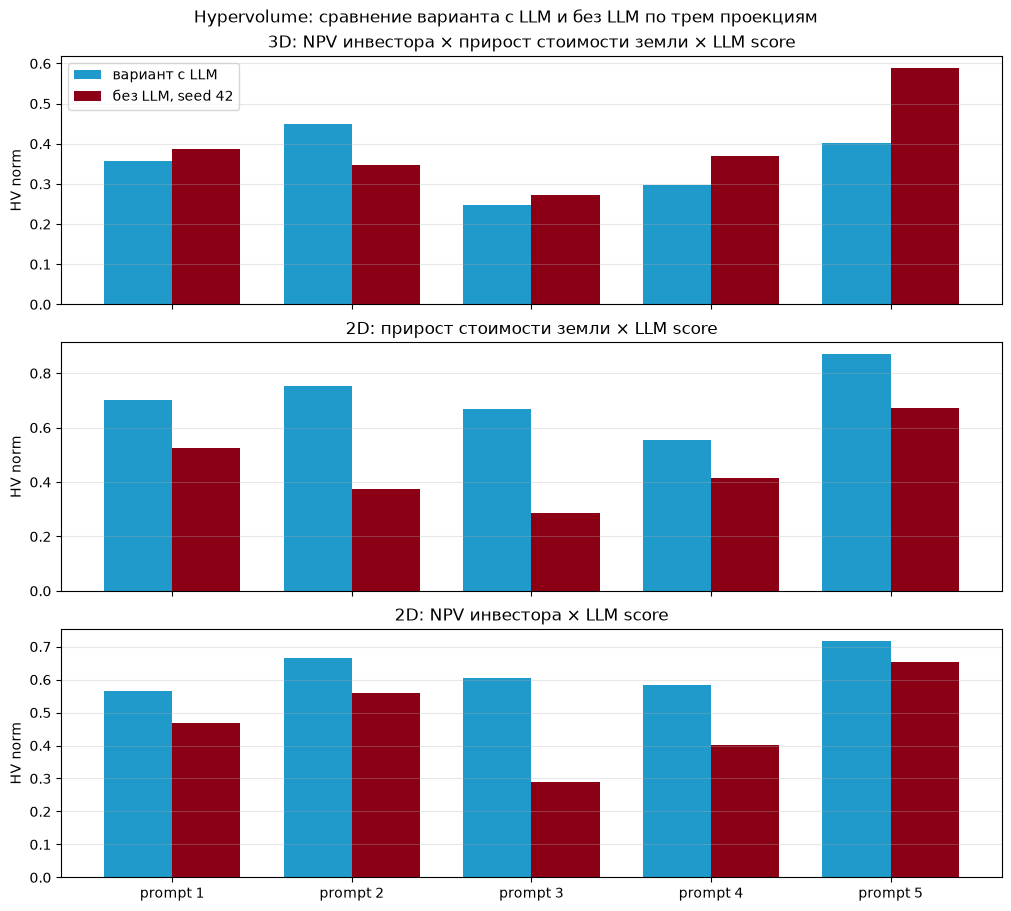

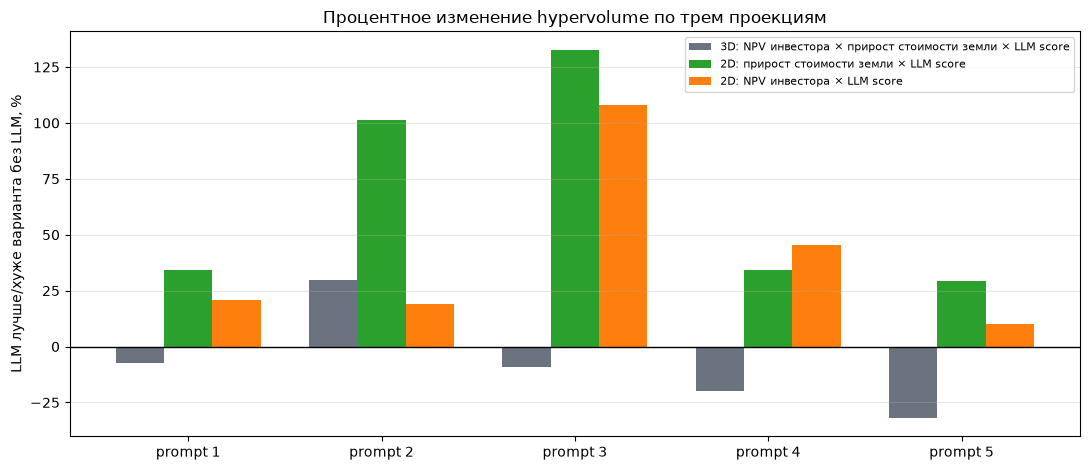

In [13]:
if "hypervolume_llm_scale" not in globals():
    raise RuntimeError("Сначала выполните ячейку с расчетом hypervolume_llm_scale")

projection_order = [
    "3D: NPV инвестора × прирост стоимости земли × LLM score",
    "2D: прирост стоимости земли × LLM score",
    "2D: NPV инвестора × LLM score",
]
plot_source = hypervolume_llm_scale.copy()

fig, axes = plt.subplots(len(projection_order), 1, figsize=(10, 9), sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)
width = 0.38

for ax, projection in zip(axes, projection_order):
    df = plot_source[plot_source["projection"] == projection].set_index("prompt_id").sort_index()
    x = np.arange(len(df))
    ax.bar(x - width / 2, df["llm_hypervolume_norm"], width, label="вариант с LLM", color="#1f9acb")
    ax.bar(x + width / 2, df["baseline_hypervolume_norm"], width, label=f"без LLM, seed {SEED}", color="#8b0015")
    ax.set_title(projection)
    ax.set_ylabel("HV norm")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks(x, [f"prompt {prompt_id}" for prompt_id in df.index])
axes[0].legend()
fig.suptitle("Hypervolume: сравнение варианта с LLM и без LLM по трем проекциям")
plt.show()

pct = plot_source.pivot(index="prompt_id", columns="projection", values="llm_better_worse_pct")[projection_order]
x = np.arange(len(pct.index))
width = 0.25
colors = ["#6b7280", "#2ca02c", "#ff7f0e"]

plt.figure(figsize=(11, 4.8))
for offset, projection, color in zip([-width, 0, width], projection_order, colors):
    plt.bar(x + offset, pct[projection], width, label=projection, color=color)
plt.axhline(0, color="black", lw=1)
plt.xticks(x, [f"prompt {prompt_id}" for prompt_id in pct.index])
plt.ylabel("LLM лучше/хуже варианта без LLM, %")
plt.title("Процентное изменение hypervolume по трем проекциям")
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


,S,scenario_id,investor_npv,land_value_gain,llm score
0,S1,no_llm_pareto_front_42_1,0.000000,1.000000,0.250
1,S2,no_llm_pareto_front_42_2,0.534148,0.739166,0.625
2,S3,no_llm_pareto_front_42_3,0.938893,0.093534,0.500
3,S4,no_llm_pareto_front_42_4,0.962733,0.001568,0.250
4,S5,no_llm_pareto_front_42_5,0.486485,0.753924,1.000
5,S6,no_llm_pareto_front_42_6,0.504944,0.743912,0.000
6,S7,no_llm_pareto_front_42_7,0.443844,0.768753,0.250
7,S8,no_llm_pareto_front_42_8,0.770421,0.721066,0.250
8,S9,no_llm_pareto_front_42_9,0.855936,0.706618,0.250
9,S10,no_llm_pareto_front_42_10,0.760856,0.729124,0.125


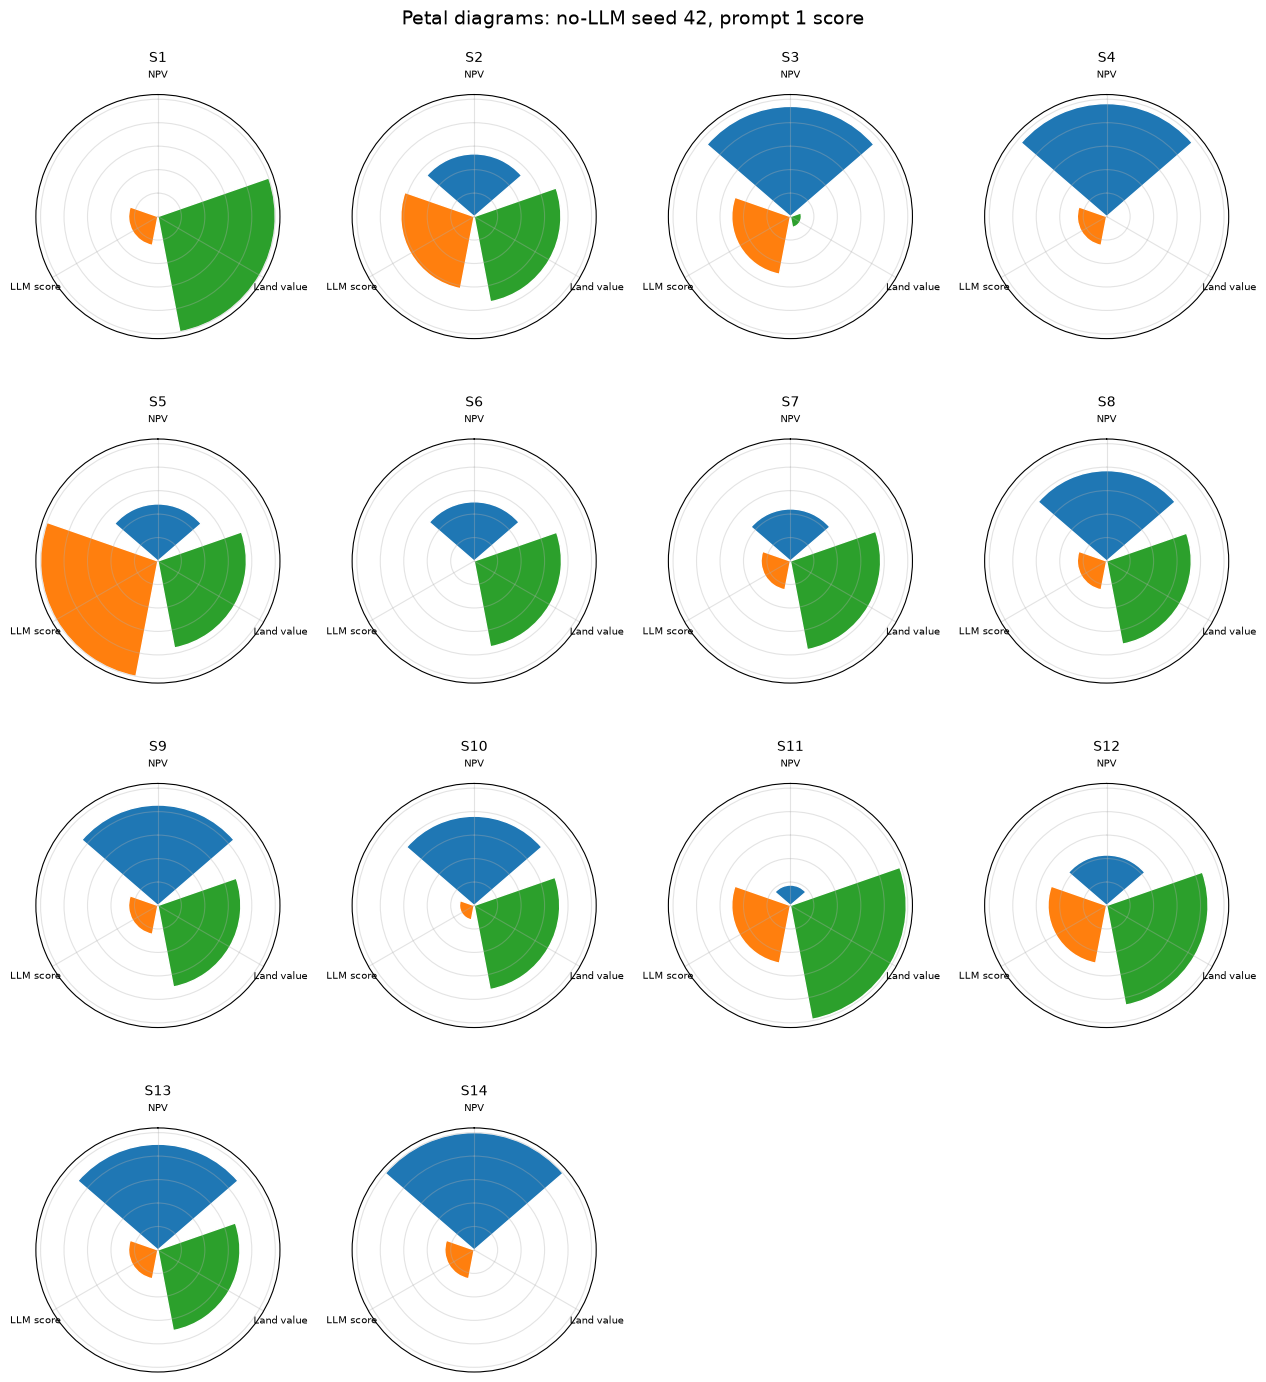

In [11]:
import math

objective_cols = ["investor_npv", "land_value_gain", "llm score"]
objective_labels = ["NPV", "Land value", "LLM score"]
objective_colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]

petal_source = scored_seed42[1].copy()
for col in objective_cols:
    petal_source[col] = pd.to_numeric(petal_source[col], errors="coerce")
petal_source = petal_source.dropna(subset=objective_cols).reset_index(drop=True)

mins = petal_source[objective_cols].min()
ranges = (petal_source[objective_cols].max() - mins).replace(0, np.nan)
petal_norm = ((petal_source[objective_cols] - mins) / ranges).fillna(0.0).clip(0, 1)
petal_scores = petal_source[["scenario_id"]].join(petal_norm)
petal_scores.insert(0, "S", [f"S{i + 1}" for i in range(len(petal_scores))])
display(petal_scores)


def draw_petal(ax, values):
    theta = np.linspace(0, 2 * np.pi, len(values), endpoint=False)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.bar(theta, values, width=2 * np.pi / len(values) * 0.82, color=objective_colors, edgecolor="white")
    ax.set_ylim(0, 1.04)
    ax.set_xticks(theta)
    ax.set_xticklabels(objective_labels, fontsize=7)
    ax.set_yticklabels([])
    ax.grid(True, alpha=0.35)

n = len(petal_scores)
ncols = min(4, n)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.6 * nrows), subplot_kw={"projection": "polar"})
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, petal_scores.iterrows()):
    draw_petal(ax, row[objective_cols].to_numpy(float))
    ax.set_title(row["S"], fontsize=10)
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(f"Petal diagrams: no-LLM seed {SEED}, prompt 1 score", fontsize=14)
fig.tight_layout()
plt.show()
